# Проект для «Викишоп»

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 

Обучите модель классифицировать комментарии на позитивные и негативные. В распоряжении набор данных с разметкой о токсичности правок.

Необходимо построить модель со значением метрики качества *F1* не меньше 0.75. 



**Содержание**
1. [Подготовка](#Подготовка)
2. [TF-IDF + логистическая регрессия](#TF-IDF)
3. [N-граммы с CountVectorizer](#N-граммы-с-CountVectorizer)
4. [BERT-эмбеддинги + логистическая регрессия](#BERT)
5. [Выводы](#Выводы)

Импорт необходимых библиотек

In [1]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import notebook

import nltk
from nltk.corpus import stopwords as nltk_stopwords
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

import torch
import transformers
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score

for resource in ['punkt', 'punkt_tab', 'wordnet', 'stopwords',
                 'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng']:
    nltk.download(resource, quiet=True)

## Подготовка

In [2]:
def load_dataset(name, **kwargs):
    """Читает датасет из локальной папки datasets/, при её отсутствии — с code.s3.yandex.net."""
    local = os.path.join('datasets', name)
    source = local if os.path.exists(local) else 'https://code.s3.yandex.net/datasets/' + name
    return pd.read_csv(source, **kwargs)

df = load_dataset('toxic_comments.csv')
df.head()

,Unnamed: 0,text,toxic
0,0,Explanation\nWhy the edits made under my usern...,0
1,1,D'aww! He matches this background colour I'm s...,0
2,2,"Hey man, I'm really not trying to edit war. It...",0
3,3,"""\nMore\nI can't make any real suggestions on ...",0
4,4,"You, sir, are my hero. Any chance you remember...",0


In [3]:
df.shape

(159292, 3)

Посмотрим на распределение целевой переменной:

<Axes: xlabel='toxic'>

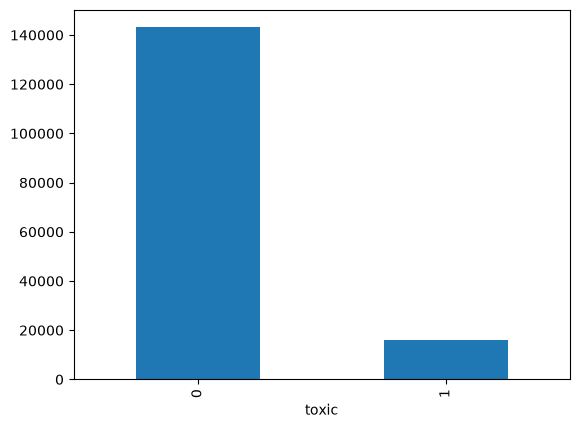

In [4]:
df.groupby(['toxic']).size().plot.bar()

Данные не сбалансированы.

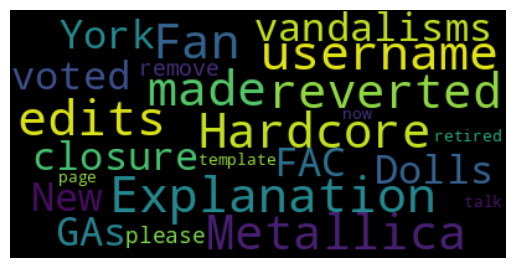

In [5]:
# облако слов для примера первого комментария
wordcloud = WordCloud(max_font_size=40).generate(df['text'][0])
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [6]:
corpus = df['text'].values.astype('U')

In [7]:
lemmatizer = WordNetLemmatizer()
TAG_DICT = {'J': wordnet.ADJ, 'N': wordnet.NOUN, 'V': wordnet.VERB, 'R': wordnet.ADV}


def clear_text(text):
    t = re.sub(r'[^a-zA-Z ]', ' ', text)
    return ' '.join(t.split()).lower()


def lemmatize(text):
    words = nltk.word_tokenize(text)
    tagged = nltk.pos_tag(words)
    return ' '.join(lemmatizer.lemmatize(w, TAG_DICT.get(tag[0].upper(), wordnet.NOUN))
                    for w, tag in tagged)


print("Исходный текст:", corpus[0])
print("Очищенный и лемматизированный текст:", lemmatize(clear_text(corpus[0])))

Исходный текст: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27
Очищенный и лемматизированный текст: explanation why the edits make under my username hardcore metallica fan be revert they weren t vandalism just closure on some gas after i vote at new york doll fac and please don t remove the template from the talk page since i m retire now


In [8]:
%%time
df['text'] = df['text'].apply(lambda x: lemmatize(clear_text(x)))

CPU times: user 3min 26s, sys: 136 ms, total: 3min 26s
Wall time: 3min 26s


In [9]:
corpus = df['text'].values.astype('U')

## TF-IDF

## Обучение

In [10]:
model = LogisticRegression(class_weight='balanced', random_state=12345, max_iter=2000)

In [11]:
stopwords = list(nltk_stopwords.words('english'))

In [12]:
%%time
best_score = 0
best_ngram = None
for i in range(2, 4):
    X_train, X_test, y_train, y_test = train_test_split(corpus, df['toxic'], test_size=0.25, random_state=12345)
    count_tf_idf = TfidfVectorizer(ngram_range=(1, i), stop_words=stopwords, max_df=0.975)
    X_train = count_tf_idf.fit_transform(X_train)
    X_test = count_tf_idf.transform(X_test)
    model.fit(X_train, y_train)
    score = f1_score(y_test, model.predict(X_test))
    print(f'ngram_range=(1, {i}): F1 = {score:.4f}')
    if best_score < score:
        best_score = score
        best_ngram = (1, i)
print(best_score, best_ngram)

ngram_range=(1, 2): F1 = 0.7448


ngram_range=(1, 3): F1 = 0.7298
0.7447928085946064 (1, 2)
CPU times: user 1min 40s, sys: 4.71 s, total: 1min 45s
Wall time: 54.2 s


In [13]:
X_train, X_test, y_train, y_test = train_test_split(corpus, df['toxic'], test_size=0.25, random_state=12345)

count_tf_idf = TfidfVectorizer(ngram_range=(1, 2), stop_words=stopwords, max_df=0.975)
X_train = count_tf_idf.fit_transform(X_train)
X_test = count_tf_idf.transform(X_test)

In [14]:
def evaluate(model, params):
    grid = GridSearchCV(model, param_grid=params, scoring='f1', cv=3, n_jobs=2)
    grid.fit(X_train, y_train)
    pred = grid.predict(X_test)
    print('F1', f1_score(y_test, pred))
    print(grid.best_params_)

In [15]:
%%time
model = LogisticRegression(class_weight='balanced', random_state=12345, max_iter=2000)
evaluate(model, {'C': np.logspace(-1, 1, 3)})

F1 0.783007766533302
{'C': np.float64(10.0)}
CPU times: user 26.6 s, sys: 232 ms, total: 26.8 s
Wall time: 35.5 s


## N-граммы с CountVectorizer

In [16]:
%%time
model = LogisticRegression(class_weight='balanced', random_state=12345, max_iter=2000)
best_score = 0
best_ngram = None
for i in range(2, 4):
    X_train, X_test, y_train, y_test = train_test_split(corpus, df['toxic'], test_size=0.25, random_state=12345)
    count_vect = CountVectorizer(ngram_range=(1, i), stop_words=stopwords, max_df=0.975, min_df=0.005)
    X_train = count_vect.fit_transform(list(X_train))
    X_test = count_vect.transform(X_test)
    model.fit(X_train, y_train)
    score = f1_score(y_test, model.predict(X_test))
    print(f'ngram_range=(1, {i}): F1 = {score:.4f}')
    if best_score < score:
        best_score = score
        best_ngram = (1, i)
print(best_score, best_ngram)

ngram_range=(1, 2): F1 = 0.4937


ngram_range=(1, 3): F1 = 0.4939
0.4938830992297236 (1, 3)
CPU times: user 32.2 s, sys: 648 ms, total: 32.9 s
Wall time: 22.7 s


In [17]:
X_train, X_test, y_train, y_test = train_test_split(corpus, df['toxic'], test_size=0.25, random_state=12345)
count_vect = CountVectorizer(ngram_range=(1, 3), stop_words=stopwords, max_df=0.975, min_df=0.005)
X_train = count_vect.fit_transform(list(X_train))
X_test = count_vect.transform(X_test)
print("Размер:", X_train.shape, X_test.shape)

Размер: (119469, 1001) (39823, 1001)


In [18]:
%%time
model = LogisticRegression(class_weight='balanced', random_state=12345, max_iter=2000)
evaluate(model, {'C': np.logspace(-1, 1, 3)})

F1 0.498089561363289
{'C': np.float64(0.1)}
CPU times: user 4.75 s, sys: 28.2 ms, total: 4.78 s
Wall time: 6.44 s


## BERT

Получим эмбеддинги предобученной модели `bert-base-uncased` и обучим на них логистическую регрессию. Инференс BERT выполняется на CPU, поэтому используем **подвыборку в 3200 комментариев** — результат ниже стоит воспринимать как эксперимент, а не как оценку на полном датасете.

In [19]:
df_bert = load_dataset('toxic_comments.csv')
df_tweets = df_bert.sample(3200, random_state=12345).reset_index(drop=True)

tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
tokenized = df_tweets['text'].apply(
    lambda x: tokenizer.encode(x, add_special_tokens=True, max_length=512, truncation=True))
df_tweets.shape, tokenized.shape

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

((3200, 3), (3200,))

In [20]:
max_len = 0
for i in tokenized.values:
    if len(i) > max_len:
        max_len = len(i)

padded = np.array([i + [0]*(max_len - len(i)) for i in tokenized.values])

attention_mask = np.where(padded != 0, 1, 0)
attention_mask.shape

(3200, 512)

In [21]:
model = transformers.BertModel.from_pretrained('bert-base-uncased')
model.eval()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
            (dropout): Dropout(p=

In [22]:
%%time
batch_size = 100
embeddings = []
n_batches = int(np.ceil(padded.shape[0] / batch_size))
for i in notebook.tqdm(range(n_batches)):
    batch = torch.LongTensor(padded[batch_size * i:batch_size * (i + 1)])
    attention_mask_batch = torch.LongTensor(attention_mask[batch_size * i:batch_size * (i + 1)])
    with torch.no_grad():
        batch_embeddings = model(batch, attention_mask=attention_mask_batch)
    embeddings.append(batch_embeddings[0][:, 0, :].numpy())

  0%|          | 0/32 [00:00<?, ?it/s]

CPU times: user 1h 8min 15s, sys: 7min 19s, total: 1h 15min 34s
Wall time: 39min 26s


In [23]:
X = np.concatenate(embeddings) 
y = df_tweets['toxic']
print(X.shape, df_tweets['toxic'].shape)

(3200, 768) (3200,)


In [24]:
model = LogisticRegression(class_weight='balanced', random_state=12345, max_iter=2000)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=12345, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1600, 768), (1600, 768), (1600,), (1600,))

In [25]:
model.fit(X_train, y_train)
print('Accuracy:', model.score(X_test, y_test))
print('F1:', f1_score(y_test, model.predict(X_test)))

Accuracy: 0.918125
F1: 0.6350974930362117


F1 BERT-эмбеддингов с логистической регрессией на подвыборке (0.64) получилась заметно ниже, чем у TF-IDF на полном датасете (0.78). Для честного сравнения BERT стоило бы дообучать (fine-tuning) на GPU и на полной выборке — здесь это оставлено как эксперимент.

## Выводы

Обучены модели классификации комментариев по токсичности:

| Подход | F1 (тест) |
|---|---|
| **TF-IDF (1–2-граммы) + LogisticRegression (C=10)** | **0.783** |
| CountVectorizer (n-граммы, min_df=0.005) + LogisticRegression | 0.50 |
| BERT-эмбеддинги + LogisticRegression (подвыборка 3200, CPU) | 0.64 |

Требование задачи (F1 ≥ 0.75) выполнено моделью **TF-IDF + логистическая регрессия**. BERT-эксперимент на подвыборке уступает TF-IDF: без fine-tuning и на малой выборке предобученные эмбеддинги не раскрывают потенциал модели.